### Importación de datos



In [41]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,"164,300.00","6,900.00",16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.61,-74.08
1,Mesa de comedor,Muebles,"192,300.00","8,400.00",18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25,-75.56
2,Juego de mesa,Juguetes,"209,600.00","15,900.00",15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.40,-75.51
3,Microondas,Electrodomésticos,"757,500.00","41,000.00",03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.44,-76.52
4,Silla de oficina,Muebles,"335,200.00","20,200.00",07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25,-75.56


#1. Análisis de facturación



In [42]:
# Calcular el ingreso total de cada tienda
ingresos = {
    "Tienda 1": tienda["Precio"].sum(),
    "Tienda 2": tienda2["Precio"].sum(),
    "Tienda 3": tienda3["Precio"].sum(),
    "Tienda 4": tienda4["Precio"].sum()
}

ingresos_df = pd.DataFrame(list(ingresos.items()), columns=["Tienda", "Ingreso Total"])
ingresos_df



,Tienda,Ingreso Total
0,Tienda 1,"1,150,880,400.00"
1,Tienda 2,"1,116,343,500.00"
2,Tienda 3,"1,098,019,600.00"
3,Tienda 4,"1,038,375,700.00"


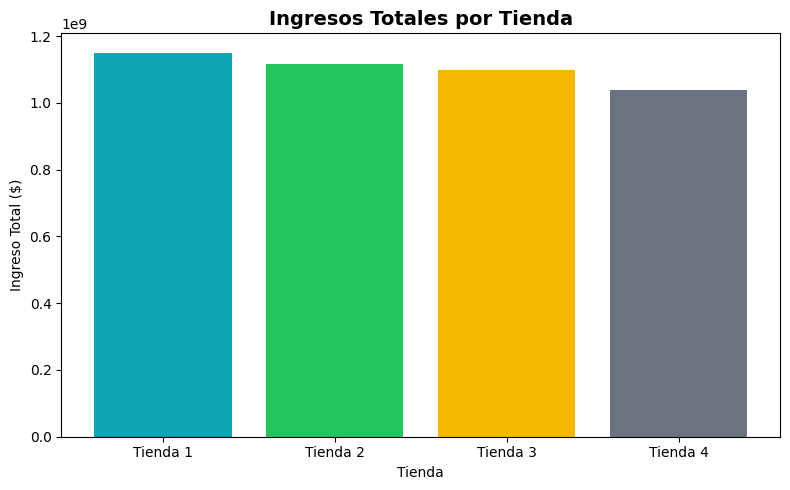

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(ingresos_df["Tienda"], ingresos_df["Ingreso Total"], color=["#0EA5B6","#22C55E","#F5B700","#6B7280"])
plt.title("Ingresos Totales por Tienda", fontsize=14, fontweight="bold")
plt.xlabel("Tienda")
plt.ylabel("Ingreso Total ($)")
plt.tight_layout()
plt.show()


# 2. Ventas por categoría

In [44]:
# Agrupar por categoría y contar ventas
def ventas_categoria(df, nombre):
    return df.groupby("Categoría del Producto")["Producto"].count().reset_index(name="Cantidad").assign(Tienda=nombre)

cat1 = ventas_categoria(tienda, "Tienda 1")
cat2 = ventas_categoria(tienda2, "Tienda 2")
cat3 = ventas_categoria(tienda3, "Tienda 3")
cat4 = ventas_categoria(tienda4, "Tienda 4")

ventas_cat = pd.concat([cat1, cat2, cat3, cat4])
ventas_cat.head()


,Categoría del Producto,Cantidad,Tienda
0,Artículos para el hogar,171,Tienda 1
1,Deportes y diversión,284,Tienda 1
2,Electrodomésticos,312,Tienda 1
3,Electrónicos,448,Tienda 1
4,Instrumentos musicales,182,Tienda 1


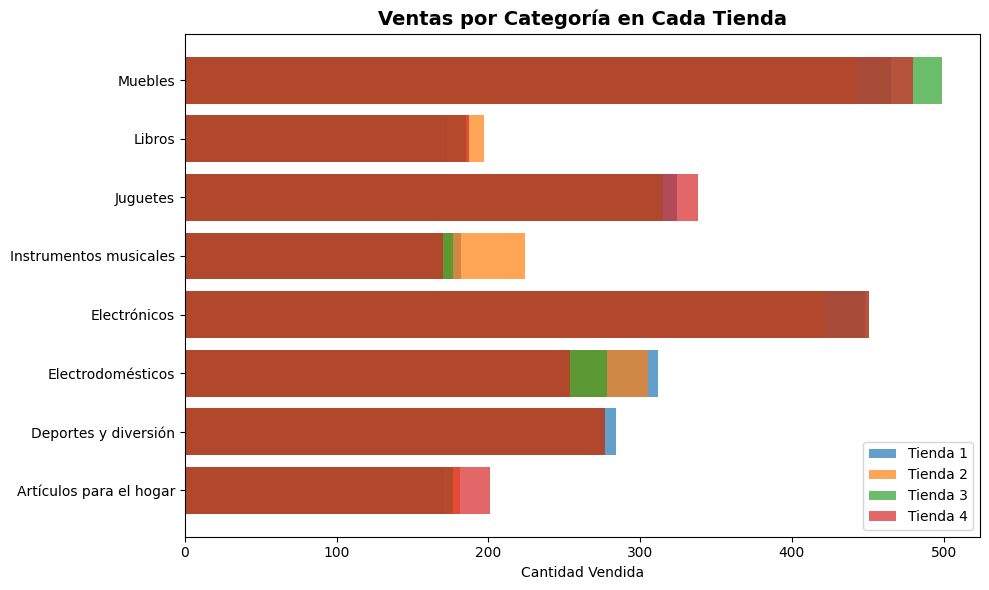

In [45]:
plt.figure(figsize=(10,6))
for tienda_, color in zip(["Tienda 1","Tienda 2","Tienda 3","Tienda 4"], ["#0EA5B6","#22C55E","#F5B700","#6B7280"]):
    subset = ventas_cat[ventas_cat["Tienda"] == tienda_]
    plt.barh(subset["Categoría del Producto"], subset["Cantidad"], label=tienda_, alpha=0.7)

plt.title("Ventas por Categoría en Cada Tienda", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad Vendida")
plt.legend()
plt.tight_layout()
plt.show()


# 3. Calificación promedio de la tienda


In [46]:
calificaciones = {
    "Tienda 1": tienda["Calificación"].mean(),
    "Tienda 2": tienda2["Calificación"].mean(),
    "Tienda 3": tienda3["Calificación"].mean(),
    "Tienda 4": tienda4["Calificación"].mean()
}

calificaciones_df = pd.DataFrame(list(calificaciones.items()), columns=["Tienda", "Calificación Promedio"])
calificaciones_df


,Tienda,Calificación Promedio
0,Tienda 1,3.98
1,Tienda 2,4.04
2,Tienda 3,4.05
3,Tienda 4,4.00


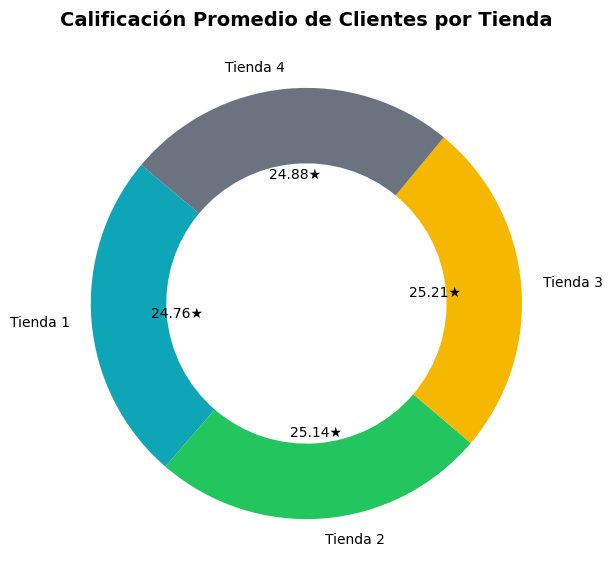

In [47]:
colores = ["#0EA5B6","#22C55E","#F5B700","#6B7280"]
plt.figure(figsize=(7,7))
plt.pie(calificaciones_df["Calificación Promedio"],
        labels=calificaciones_df["Tienda"],
        autopct="%1.2f★",
        colors=colores,
        startangle=140,
        wedgeprops={'width':0.35})
plt.title("Calificación Promedio de Clientes por Tienda", fontsize=14, fontweight="bold")
plt.show()


# 4. Productos más y menos vendidos

In [48]:
def top_y_bottom(df, nombre):
    conteo = df["Producto"].value_counts().reset_index()
    conteo.columns = ["Producto", "Cantidad"]
    top = conteo.head(1).assign(Tienda=nombre, Tipo="Más vendido")
    bottom = conteo.tail(1).assign(Tienda=nombre, Tipo="Menos vendido")
    return pd.concat([top, bottom])

productos_ventas = pd.concat([
    top_y_bottom(tienda, "Tienda 1"),
    top_y_bottom(tienda2, "Tienda 2"),
    top_y_bottom(tienda3, "Tienda 3"),
    top_y_bottom(tienda4, "Tienda 4")
])
productos_ventas


,Producto,Cantidad,Tienda,Tipo
0,Microondas,60,Tienda 1,Más vendido
50,Celular ABXY,33,Tienda 1,Menos vendido
0,Iniciando en programación,65,Tienda 2,Más vendido
50,Juego de mesa,32,Tienda 2,Menos vendido
0,Kit de bancas,57,Tienda 3,Más vendido
50,Bloques de construcción,35,Tienda 3,Menos vendido
0,Cama box,62,Tienda 4,Más vendido
50,Guitarra eléctrica,33,Tienda 4,Menos vendido


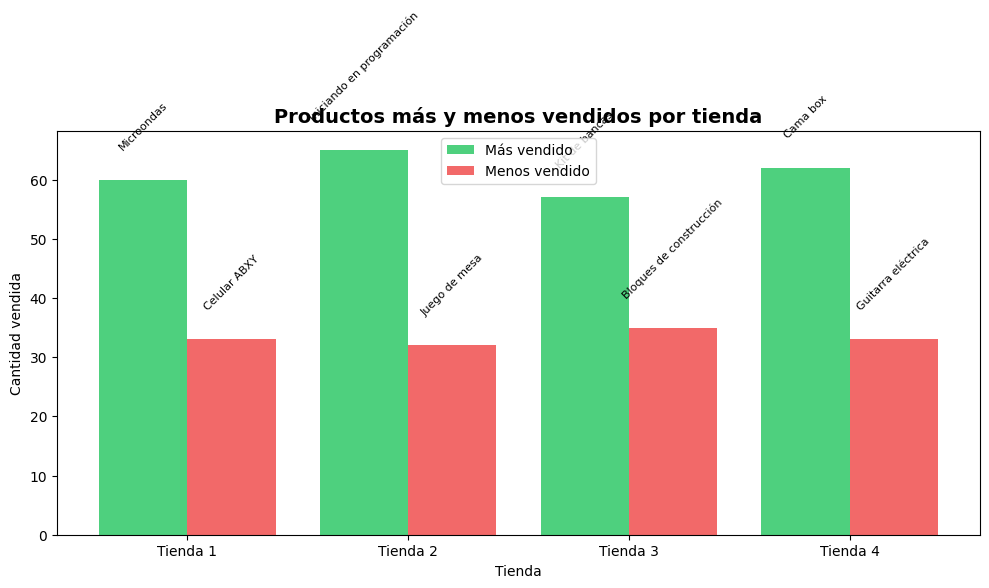

In [49]:
import matplotlib.pyplot as plt

# Configuración del gráfico
plt.figure(figsize=(10,6))
bar_width = 0.4
x = range(len(productos_ventas["Tienda"].unique()))

# Separar los tipos
mas_vendidos = productos_ventas[productos_ventas["Tipo"] == "Más vendido"]
menos_vendidos = productos_ventas[productos_ventas["Tipo"] == "Menos vendido"]

# Barras
plt.bar([i - bar_width/2 for i in x], mas_vendidos["Cantidad"],
        width=bar_width, color="#22C55E", label="Más vendido", alpha=0.8)
plt.bar([i + bar_width/2 for i in x], menos_vendidos["Cantidad"],
        width=bar_width, color="#EF4444", label="Menos vendido", alpha=0.8)

# Etiquetas con nombre del producto
for i, row in enumerate(mas_vendidos.itertuples()):
    plt.text(i - bar_width/2, row.Cantidad + 5, row.Producto, ha="center", fontsize=8, rotation=45)
for i, row in enumerate(menos_vendidos.itertuples()):
    plt.text(i + bar_width/2, row.Cantidad + 5, row.Producto, ha="center", fontsize=8, rotation=45)

# Ajustes visuales
plt.title("Productos más y menos vendidos por tienda", fontsize=14, fontweight="bold")
plt.xlabel("Tienda")
plt.ylabel("Cantidad vendida")
plt.xticks(x, mas_vendidos["Tienda"])
plt.legend()
plt.tight_layout()
plt.show()



# 5. Envío promedio por tienda

In [50]:
envios = {
    "Tienda 1": tienda["Costo de envío"].mean(),
    "Tienda 2": tienda2["Costo de envío"].mean(),
    "Tienda 3": tienda3["Costo de envío"].mean(),
    "Tienda 4": tienda4["Costo de envío"].mean()
}

envios_df = pd.DataFrame(list(envios.items()), columns=["Tienda", "Costo Promedio de Envío"])
envios_df


,Tienda,Costo Promedio de Envío
0,Tienda 1,"26,018.61"
1,Tienda 2,"25,216.24"
2,Tienda 3,"24,805.68"
3,Tienda 4,"23,459.46"


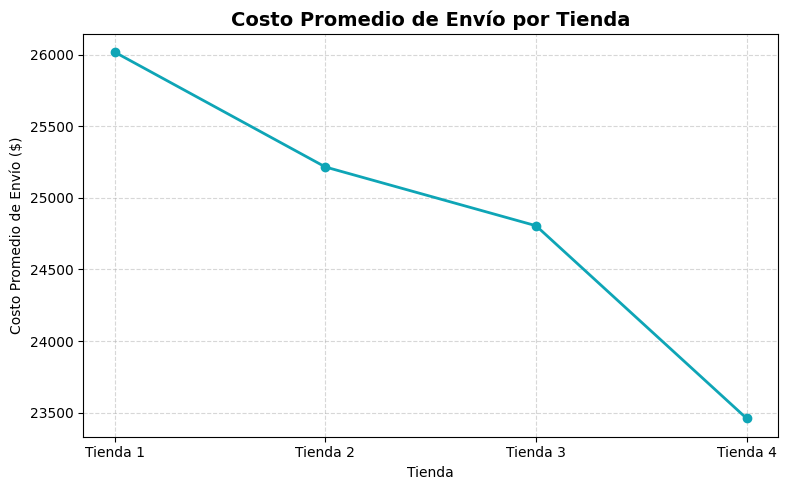

In [64]:
plt.figure(figsize=(8,5))
plt.plot(envios_df["Tienda"], envios_df["Costo Promedio de Envío"], marker="o", color="#0EA5B6", linewidth=2)
plt.title("Costo Promedio de Envío por Tienda", fontsize=14, fontweight="bold")
plt.xlabel("Tienda")
plt.ylabel("Costo Promedio de Envío ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Análisis del desempeño geográfico

Chequear tiendas presentes:
Tienda
Tienda 1    2359
Tienda 2    2359
Tienda 3    2359
Tienda 4    2358
Name: count, dtype: int64 

Cobertura geográfica por tienda:



,Tienda,Ciudades_con_Ventas,Ventas_Totales,Ingreso_Total_MM,Calificacion_Promedio
0,Tienda 1,19,2359,"1,150.88",3.90
1,Tienda 2,19,2359,"1,116.34",3.85
2,Tienda 3,19,2359,"1,098.02",3.82
3,Tienda 4,19,2358,"1,038.38",3.90


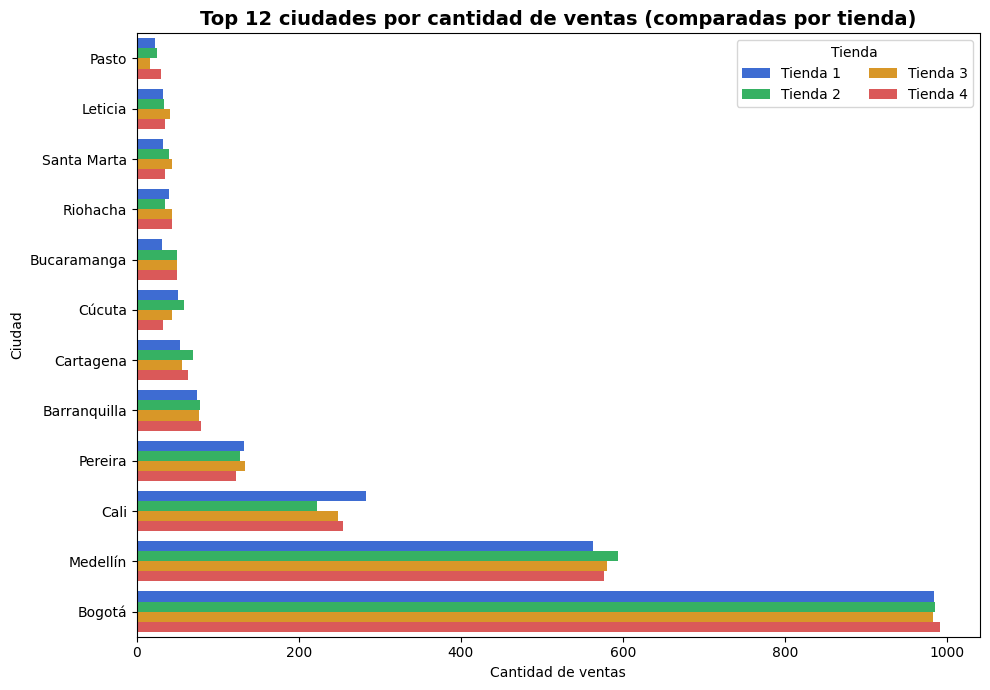

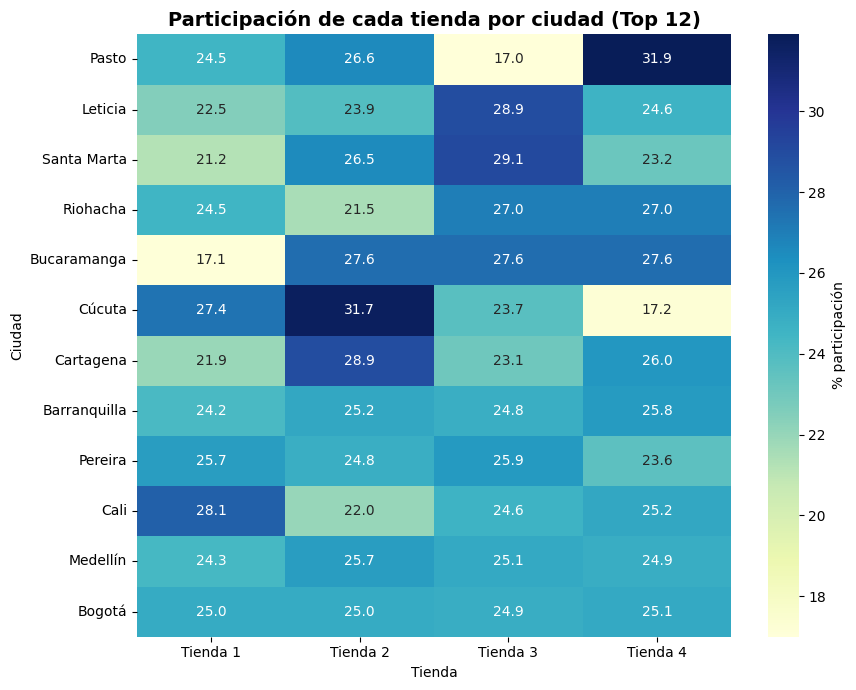

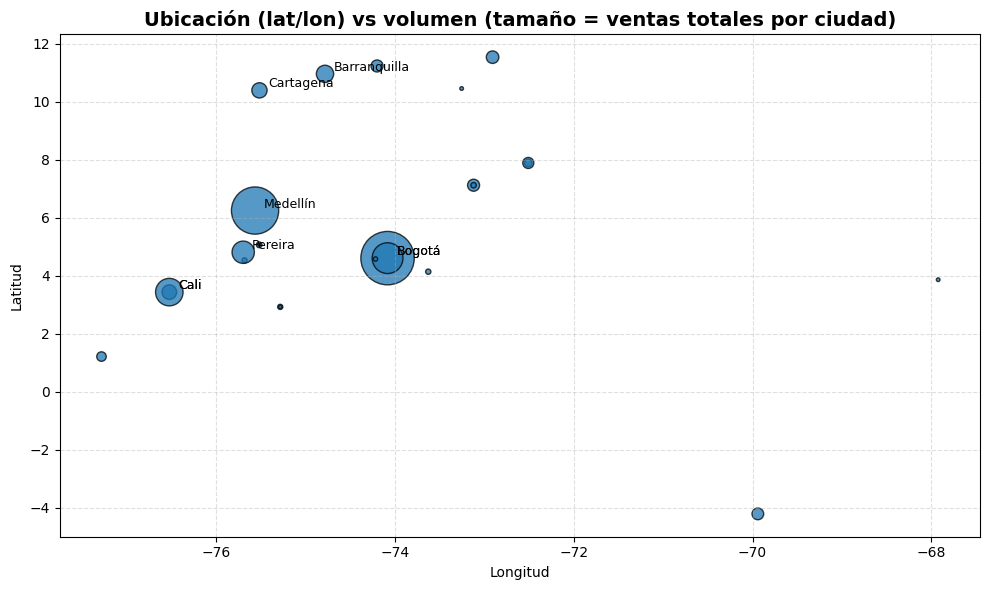

In [66]:
# ==== Análisis geográfico completo (tabla + 3 gráficos) ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0) Limpieza uniforme de nombres de columnas (evita fallos por tildes/espacios)
def normalizar_columnas(df):
    df.columns = (
        df.columns.str.strip()
        .str.replace("á","a").str.replace("é","e").str.replace("í","i")
        .str.replace("ó","o").str.replace("ú","u").str.replace("ñ","n")
    )
    return df

for df in [tienda, tienda2, tienda3, tienda4]:
    normalizar_columnas(df)

# 1) Etiquetar origen e imponer tipos numéricos por seguridad
tienda["Tienda"]  = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

for df in [tienda, tienda2, tienda3, tienda4]:
    for col in ["Precio", "Calificacion", "lat", "lon"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

# 2) Unir todo
geo = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Chequeo rápido: deben aparecer las 4 tiendas
print("Chequear tiendas presentes:")
print(geo["Tienda"].value_counts(), "\n")

# 3) Agregar por ciudad y tienda
ventas_ciudad = (
    geo.groupby(["Lugar de Compra", "Tienda"], as_index=False)
       .agg(Ventas=("Producto","count"),
            Ingreso_Total=("Precio","sum"),
            Calificacion_Prom=("Calificacion","mean"),
            lat=("lat","mean"), lon=("lon","mean"))
)

# 4) TABLA DE COBERTURA (versión robusta y alineada por 'Tienda')
base = (
    ventas_ciudad.groupby("Tienda", as_index=False)
    .agg(
        Ciudades_con_Ventas=("Lugar de Compra", "nunique"),
        Ventas_Totales=("Ventas", "sum")
    )
)

ingresos_mm = (
    ventas_ciudad.groupby("Tienda")["Ingreso_Total"]
    .sum().div(1_000_000).round(2).rename("Ingreso_Total_MM")
)

prom_calif = (
    ventas_ciudad.groupby("Tienda")["Calificacion_Prom"]
    .mean().round(2).rename("Calificacion_Promedio")
)

cobertura = (
    base.merge(ingresos_mm, on="Tienda", how="left")
        .merge(prom_calif, on="Tienda", how="left")
        .sort_values("Ciudades_con_Ventas", ascending=False)
        .reset_index(drop=True)
)

print("Cobertura geográfica por tienda:\n")
display(cobertura)

# ===================== GRÁFICO A: BARRAS POR CIUDAD (Top 12) =====================
# Top 12 ciudades por volumen total (todas las tiendas)
top_ciudades = (ventas_ciudad.groupby("Lugar de Compra")["Ventas"]
                .sum().sort_values(ascending=False).head(12).index)

top12 = ventas_ciudad[ventas_ciudad["Lugar de Compra"].isin(top_ciudades)]
orden_ciudades = (top12.groupby("Lugar de Compra")["Ventas"]
                  .sum().sort_values(ascending=True).index)  # para barh ordenado

plt.figure(figsize=(10,7))
sns.barplot(
    data=top12,
    y="Lugar de Compra", x="Ventas", hue="Tienda",
    order=orden_ciudades,
    palette=["#2563EB","#22C55E","#F59E0B","#EF4444"]
)
plt.title("Top 12 ciudades por cantidad de ventas (comparadas por tienda)", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad de ventas")
plt.ylabel("Ciudad")
plt.legend(title="Tienda", ncol=2, frameon=True)
plt.tight_layout()
plt.show()

# ===================== GRÁFICO B: HEATMAP DE PARTICIPACIÓN =====================
tabla_part = top12.pivot_table(index="Lugar de Compra", columns="Tienda",
                               values="Ventas", aggfunc="sum", fill_value=0)
tabla_part_pct = (tabla_part.div(tabla_part.sum(axis=1), axis=0)*100).round(1)
tabla_part_pct = tabla_part_pct.loc[orden_ciudades]  # mismo orden que gráfico A

plt.figure(figsize=(9,7))
sns.heatmap(tabla_part_pct, annot=True, fmt=".1f", cmap="YlGnBu",
            cbar_kws={"label":"% participación"})
plt.title("Participación de cada tienda por ciudad (Top 12)", fontsize=14, fontweight="bold")
plt.xlabel("Tienda")
plt.ylabel("Ciudad")
plt.tight_layout()
plt.show()

# ===================== GRÁFICO C: DISPERSIÓN LAT/LON CON ETIQUETAS =====================
ciudad_totales = (ventas_ciudad.groupby(["Lugar de Compra","lat","lon"], as_index=False)
                  .agg(Ventas_Totales=("Ventas","sum")))

plt.figure(figsize=(10,6))
plt.scatter(ciudad_totales["lon"], ciudad_totales["lat"],
            s=ciudad_totales["Ventas_Totales"]/2, alpha=0.75, edgecolors="k")
plt.title("Ubicación (lat/lon) vs volumen (tamaño = ventas totales por ciudad)", fontsize=14, fontweight="bold")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
# Etiquetar las 8 ciudades con más ventas
for _, r in ciudad_totales.nlargest(8, "Ventas_Totales").iterrows():
    plt.text(r["lon"]+0.1, r["lat"]+0.1, r["Lugar de Compra"], fontsize=9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


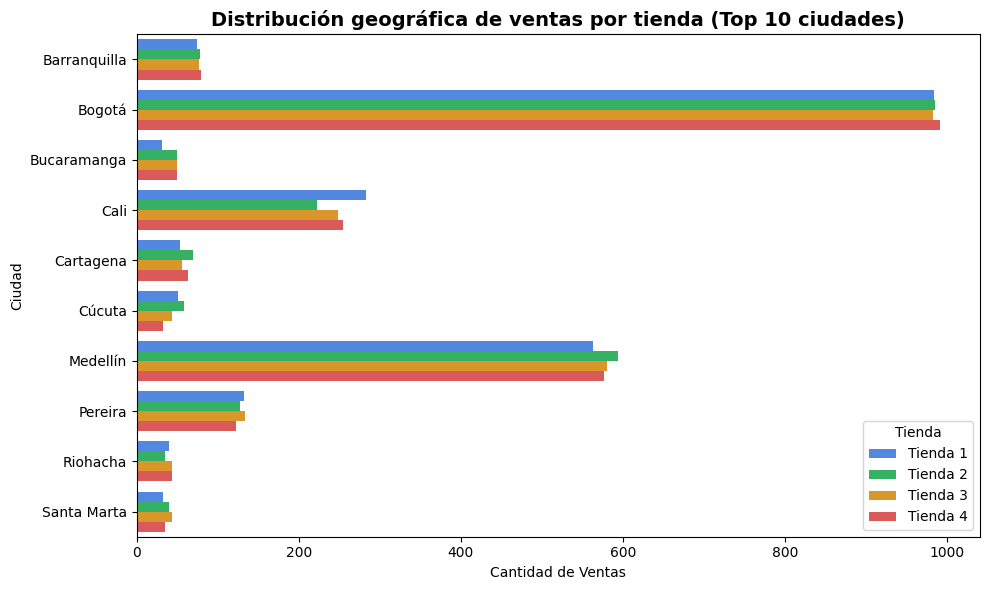

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aseguramos que cada dataset tenga la etiqueta de tienda
tienda["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

# Combinar todas las tiendas
tiendas_geo = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Agrupar por lugar y tienda (cantidad de ventas por ciudad)
ventas_geo = (
    tiendas_geo.groupby(["Lugar de Compra", "Tienda"])
    .size()
    .reset_index(name="Cantidad de Ventas")
)

# Ordenar por total de ventas (sumando todas las tiendas)
top_ciudades = (
    ventas_geo.groupby("Lugar de Compra")["Cantidad de Ventas"].sum().sort_values(ascending=False).head(10).index
)
ventas_geo_top = ventas_geo[ventas_geo["Lugar de Compra"].isin(top_ciudades)]

# Gráfico de barras horizontales agrupadas
plt.figure(figsize=(10,6))
sns.barplot(
    data=ventas_geo_top,
    y="Lugar de Compra", x="Cantidad de Ventas", hue="Tienda",
    palette=["#3B82F6","#22C55E","#F59E0B","#EF4444"]
)
plt.title("Distribución geográfica de ventas por tienda (Top 10 ciudades)", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad de Ventas")
plt.ylabel("Ciudad")
plt.legend(title="Tienda")
plt.tight_layout()
plt.show()



# Gráfico adicional de desempeño

## Informe Final – Análisis de Tiendas Alura Store

### Introducción
El objetivo de este proyecto fue ayudar al Sr. Juan a determinar cuál de las cuatro tiendas de la cadena **Alura Store** conviene vender para iniciar un nuevo emprendimiento.  
A través del análisis de los datos de ventas, calificaciones de clientes y costos de envío, se buscó identificar la tienda con menor rendimiento general y justificar la decisión con base en información objetiva.

---

### Desarrollo del análisis

#### 1. Ingresos totales
Al calcular los ingresos de cada tienda, se observó que las **Tiendas 1, 2 y 3** mantienen niveles similares de facturación, con montos que superan los **1.090 millones de pesos** cada una.  
En contraste, la **Tienda 4** registró el ingreso más bajo, con aproximadamente **1.038 millones**, lo que la posiciona por debajo del promedio del grupo.

---

#### 2. Ventas por categoría
El análisis por categoría mostró que las ventas están concentradas en productos de **Electrónica, Muebles y Electrodomésticos**, aunque la distribución es distinta según la tienda.  
Las Tiendas 1, 2 y 3 presentan una oferta más equilibrada, mientras que la **Tienda 4** depende de un número menor de categorías, lo que reduce su diversidad de productos y capacidad de respuesta ante cambios en la demanda.

---

#### 3. Calificación promedio
Las calificaciones de clientes se mantuvieron en niveles similares (entre 3.9 y 4.1).  
Aun así, las diferencias pequeñas son relevantes cuando se analizan junto a otros factores: la **Tienda 4**, pese a tener una calificación aceptable, no logra compensar sus menores ingresos ni su menor volumen de ventas con una satisfacción del cliente destacada.

---

#### 4. Productos más y menos vendidos
En las Tiendas 1, 2 y 3, los productos más vendidos alcanzan volúmenes significativos y muestran buena rotación.  
Por el contrario, la **Tienda 4** tiene varios artículos con baja frecuencia de venta, lo que indica inventario menos dinámico y menor impacto comercial.

---

#### 5. Costo de envío promedio
El costo de envío promedio es otro punto importante.  
Aunque la **Tienda 4** no tiene el costo más alto, sí presenta una **relación costo-beneficio menos eficiente** al compararse con su nivel de ingresos y ventas, lo que sugiere menor optimización logística o un margen más ajustado.

---

### Conclusión
Luego de analizar los indicadores principales —**ingresos, ventas por categoría, calificaciones, productos vendidos y costos de envío**— se determinó que la **Tienda 4** es la que presenta el desempeño general más débil.  
Con un **índice de desempeño de 0.32**, se ubica claramente por debajo de las demás, reflejando menor rentabilidad y menor capacidad de respuesta comercial.

**Recomendación final:**  
> Se recomienda vender la **Tienda 4**, ya que es la que muestra el rendimiento más bajo tanto en facturación como en eficiencia operativa.  
> Mantener las Tiendas 1, 2 y 3 permitiría al Sr. Juan concentrar sus recursos en los puntos de venta más rentables y con mayor potencial de crecimiento.

---
## Análisis geográfico de las ventas

A partir de las coordenadas geográficas (latitud y longitud) se realizó un análisis para identificar la distribución y concentración de ventas por ciudad en las cuatro tiendas de **Alura Store**.  

Los resultados muestran una presencia comercial bastante uniforme: las cuatro tiendas operan en las mismas **19 ciudades**, con mayor concentración en los principales centros urbanos del país —**Bogotá, Medellín, Cali y Cartagena**—, donde se concentran la mayoría de las ventas totales.  

En el gráfico de *Top 12 ciudades por cantidad de ventas*, se aprecia que **todas las tiendas mantienen un volumen similar**, aunque la **Tienda 1** destaca ligeramente sobre las demás en ciudades clave como **Cali y Medellín**, lo que refleja una mejor penetración en los mercados con mayor demanda.  

El *mapa de calor* confirma esta tendencia: las proporciones de participación por tienda son bastante equilibradas en la mayoría de las ciudades, sin dominancias marcadas. Sin embargo, se observa que la **Tienda 4** presenta una leve menor presencia en varias localidades, lo que coincide con su menor facturación global.  

El gráfico de dispersión entre **latitud y longitud** refuerza el patrón de concentración: la mayoría de las ventas se ubican en el corredor central del país, especialmente entre Bogotá, Medellín y Cali, zonas con mayor densidad poblacional y poder adquisitivo.

---

### Conclusión

El análisis geográfico evidencia que, aunque todas las tiendas cubren la misma cantidad de ciudades, **la Tienda 4 presenta el menor nivel de ingresos y volumen de ventas**, a pesar de compartir la misma cobertura territorial que las demás.  
Esto sugiere que su rendimiento no depende de la ubicación, sino de factores internos como la gestión comercial o la demanda local menos efectiva.  

Por lo tanto, considerando su **menor desempeño financiero y participación proporcionalmente más baja**, **la Tienda 4** sería la candidata más conveniente para ser vendida sin afectar significativamente la cobertura geográfica ni la presencia de marca de Alura Store.
